# 神经网络性能优化技术  
我们已经学习了神经网络的基础概念，并了解了如何利用 PyTorch 库构建实用神经网络模型。同时我们还提到了，有多种超参数可以影响神经网络的准确率。在本节中，我们将使用 Fashion MNIST 数据集，用于构建神经网络模型执行图像分类任务，并对比使用不同参数训练模型的性能差异。  
## 1.数据准备   
### 1.1数据集分析  
Fashion MNIST 数据集是一个用于图像分类任务的经典数据集，它包含了10个类别的时尚服饰图像。每个样本都是一张28 x 28像素的灰度图像，总共有60000个训练样本和10000个测试样本。由于其简单易用的特点，Fashion MNIST数据集已经成为学术界和研究人员常用的基准数据集之一，可以用于验证图像分类算法的性能。  
### 1.2 数据集加载  
1. 首先下载数据集并导入相关库，torchvision库包含多个机器学习数据集，其中包括Fashion MNIST数据集：

In [235]:
from torchvision import datasets
import torch
data_folder = './Start-with-Pytorch/Dataset'
fmnist = datasets.FashionMNIST(data_folder, download = True, train=True)

在以上代码中，指定了要储存下载数据集的文件夹(data_folder)。接下来，利用datasets.FashionMNIST获取fmnist数据并将其储存在data_folder中 。此外，通过参数 train = True指定其只下载训练图像 

2. 接下来，将fmnist.data中可用的图像存储为tr_images，并 将对应的图像标签(fmnist.targets)存储为tr_targets:

In [236]:
 
tr_images = fmnist.data
tr_targets = fmnist.targets

3. 检查加载后的张量数据

In [237]:

unique_values = tr_targets.unique()
print(f'tr_images & tr_targets:\n\tX - {tr_images.shape}\n\tY - {tr_targets.shape}\n\tY - Unique Values : {unique_values}')
print(f'TASK:\n\t{len(unique_values)} class Classification')
print(f'UNIQUE CLASSES:\n\t{fmnist.classes}')

tr_images & tr_targets:
	X - torch.Size([60000, 28, 28])
	Y - torch.Size([60000])
	Y - Unique Values : tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
TASK:
	10 class Classification
UNIQUE CLASSES:
	['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


在以上结果中，可以看出训练数据集有60000张图像，每张图像的大小为28 x 28，且包含10个可能的类别，tr_targets包含每个图像的类别标签(以数值表示)，而fmnist.classes表示与tr_targets中的每个数值对应的类别名称。

4. 绘制随机样本图像  
- 导入相关用于绘制图像以及处理图像数组：

In [238]:

import matplotlib.pyplot as plt
import numpy as np

- 创建一个10 x  10的网格图像，其中网格的每一行对应一个类别，遍历所有类别(label_class)并获取与给定类别对应的行索引(label_x_rows):

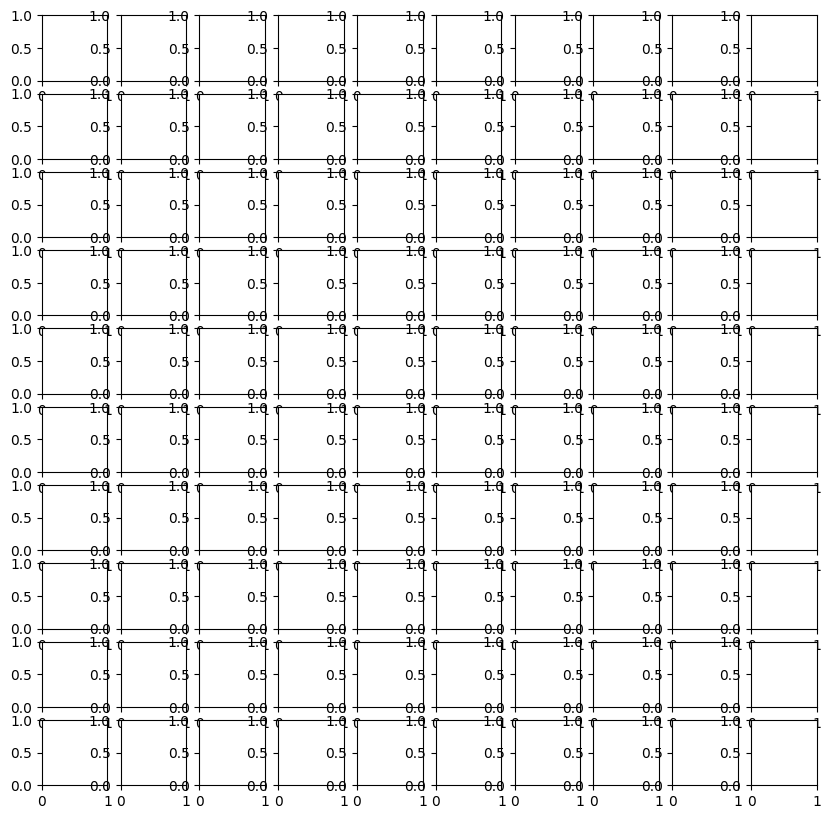

In [239]:

R, C = len(tr_targets.unique()), 10
fig, ax = plt.subplots(R, C, figsize=(10,10))
for label_class, plot_row in enumerate(ax):
    label_x_rows = np.where(tr_targets == label_class)[0]

在以上代码中，获取np.where输出的第0个索引（因为其输出的长度为1），它包含目标值(tr_targets)等于label_class的所有索引。

- 循环10次填充所有图像网格，我们从先前获得的给定类的索引(label_x_rows)中选择一个随机值(ix)并绘制：

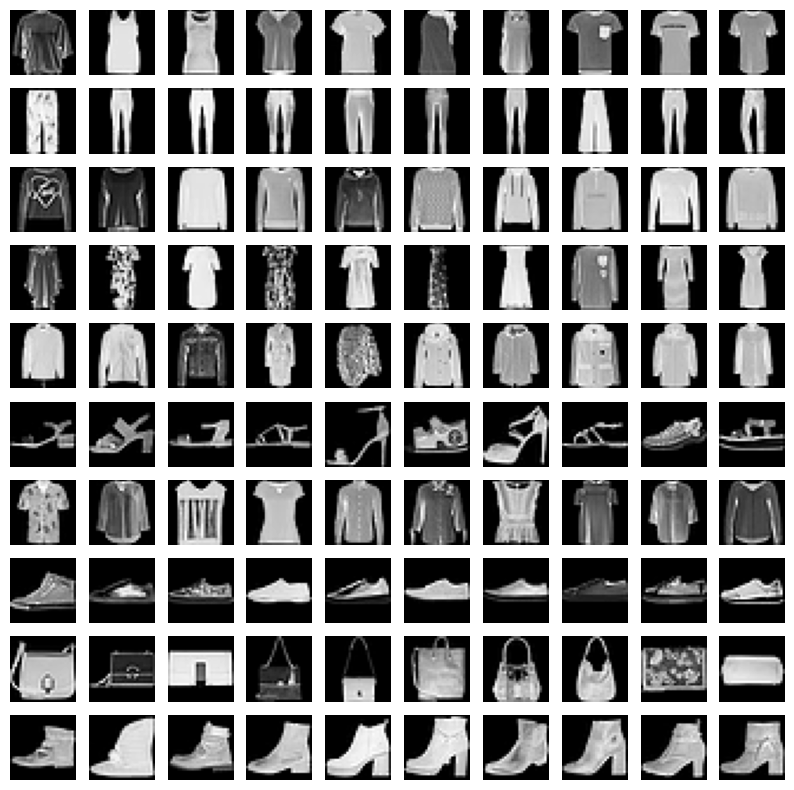

In [240]:
R, C = len(tr_targets.unique()), 10
fig, ax = plt.subplots(R, C, figsize=(10,10))

for label_class, plot_row in enumerate(ax):

    label_x_rows = np.where(tr_targets == label_class)[0]

    for plot_cell in plot_row:
        plot_cell.grid(False)
        plot_cell.axis('off')

        ix = np.random.choice(label_x_rows)
        x = tr_images[ix]

        plot_cell.imshow(x, cmap='gray')

plt.show()

在上图中，每一行代表属于同一类的10个不同图像的样本

## 2. 使用Pytorch训练神经网络  
接下来，将介绍如何使用 PyTorch 训练神经网络，以便根据输入图像预测图像类别。此外，我们还将了解各种超参数对模型预测准确率的影响。

### 2.1 神经网络训练流程  
使用Pytorch训练神经网络，通常需要执行一下步骤：
- 导入相关库
- 构建数据集，一次获取一个数据点
- 使用DataLoader封装数据集
- 构建模型，并且定义损失函数和优化器
- 定义两个函数分别 用于在一批数据上进行训练和验证
- 在每批数据训练过程中更新权重，通过多个epoch的迭代训练模型

### 2.2 Pytorch神经网络训练  
1. 导入相关库和Fashion MNIST数据集：

In [241]:
from torch.utils.data import Dataset, DataLoader 
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = 'cpu'

from torchvision import datasets
data_folder = './Start-with-Pytorch/Dataset'
fmnist = datasets.FashionMNIST(data_folder, download = True, train=True)

tr_images = fmnist.data
tr_targets = fmnist.targets

2. 构建一个用于获取数据集的类，它继承自Dataset类，且需要定义以下三个函数，\_\_init\_\_ \_\_getitem\_\_和\_\_len\_\_:

In [242]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28*28)
        self.x, self.y = x, y
    def __getitem__(self, index):
        x, y = self.x[index], self.y[index]
        return x.to(device), y.to(device)
    def __len__(self):
        return len(self.x)

在 init 方法中，将输入转换为浮点数，并将每个图像展平为 28*28 = 784 个数值(其中每个数值对应一个像素值)；在 len 方法中指定数据数量；getitem 方法用于返回第 index 个索引对应的数据( index 为 0 到 len 之间的整数)。

3. 创建函数，从数据集(FMNISTDataset)中生成一个训练数据DataLoader——trn_dl,每批数据包含随机采样的32个数据点：

In [243]:
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl

在以上代码中，创建了FMNISTDataset类的对象train，并调用了DATALoader，使其随机获取32个数据点并返回训练DataLoader。

4. 定义模型，以及损失函数和优化器

In [244]:
from torch.optim import SGD
def get_model():
    model = nn.Sequential(
        nn.Linear(28*28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer

模型使用了一个具有 1,000 个神经元的隐藏层，输出层包含 10 个神经元，对应于 10 个可能的类别。由于输出结果表示输入图像属于 10 个类别的概率，因此调用 CrossEntropyLoss 损失函数。最后，将学习率 lr 初始化为 0.01，而不使用默认值 0.001。

在神经网络中并未使用 “softmax” 函数(因此模型输出范围不受限制，而交叉熵损失通常期望输出为概率——每一图像的预测结果之和 1)，这是因为 nn.CrossEntropyLoss 接受原始 logits (即不受约束的值)并在内部执行 softmax。

5. 定义将在一批图像上训练模型的函数：

In [245]:
def train_batch(x, y, model, optimizer, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item()

在前向传播中通过模型处理输入图像，计算输入批数据损失，然后通过反向传播计算梯度并更新权重，最后刷新梯度的内存，以免对下一次传递中计算梯度时产生影响。可以通过在 batch_loss 之上获取 batch_loss.item() 提取标量损失值。

6. 编写函数计算模型在给定数据集上的准确率和损失值：

In [246]:
@torch.no_grad()#关闭梯度
def accuracy(x, y, model):
    model.eval()#关闭dropout / BN
    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)#找预测类别
    is_correct = argmaxes == y#判断是否预测正确
    return is_correct.cpu().numpy().tolist()
@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    prediction = model(x)
    val_loss = loss_fn(prediction, y)
    return val_loss.item()#取出标量值

在以上代码中，通过使用 @torch.no_grad() 显式的声明无需进行梯度计算。调用 prediction.max(-1) 来识别每行对应的 argmax 索引；此外，通过 argmaxes == y 将预测结果 argmaxes 与真实值( ground true )进行比较，以便检查是否得到正确预测。最后，将 is_correct 对象列表移动到 CPU 中并将其转换为 numpy 数组后返回。

7. 训练神经网络  
- 首先初始化模型、损失、优化器和数据加载器：

In [247]:
trn_dl = get_data()
model, loss_fn, optimizer = get_model()

- 在每个epoch结束时记录准确率和损失值：

In [248]:
losses, accuracies = [],[]

- 定义训练模型的epoch数目

In [249]:
num_epochs = 10
for epoch in range(10):
    print(epoch)

0
1
2
3
4
5
6
7
8
9


- 初始化列表用于记录一个 epoch 内每批数据对应的准确率和损失值：

In [250]:
epoch_losses, epoch_accuracies = [], []

- 通过迭代DataLoader创建批训练数据：

In [251]:
for index, batch in enumerate(iter(trn_dl)):
    x, y = batch

- 使用train_batch函数利用批数据训练模型，并将批训练结束时的损失值 batch_loss存储在epoch_losses列表中： 

In [252]:
batch_loss = train_batch(x, y, model, optimizer, loss_fn)
epoch_losses.append(batch_loss)

- 存储一个 epoch 内所有批训练的平均损失值：

In [253]:
epoch_loss = np.array(epoch_losses).mean()

- 在所有批训练结束时计算预测的准确率： 

In [254]:
for index, batch in enumerate(iter(trn_dl)):
    x, y = batch
    is_correct = accuracy(x, y, model)
    epoch_accuracies.extend(is_correct)
    epoch_accuracy = np.mean(epoch_accuracies)

- 将每个epoch结束时的损失和准确率存储在列表中：

In [255]:
losses.append(epoch_loss)
accuracies.append(epoch_accuracy)

8. 绘制训练损失和准确率随时间的变化情况：

0
1
2
3
4
5
6
7
8
9


C:\Users\Admin\AppData\Local\Temp\ipykernel_26548\2402556131.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


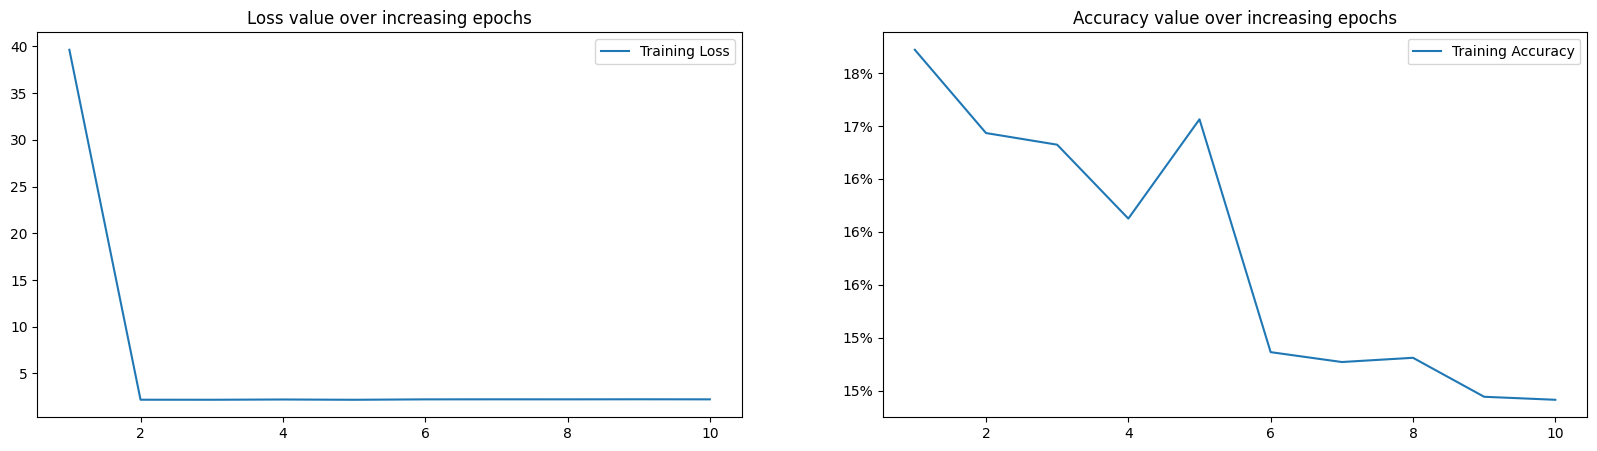

In [256]:
from torch.utils.data import Dataset, DataLoader 
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = 'cpu'

from torchvision import datasets
data_folder = './Start-with-Pytorch/Dataset'
fmnist = datasets.FashionMNIST(data_folder, download = True, train=True)

tr_images = fmnist.data
tr_targets = fmnist.targets
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28*28)
        self.x, self.y = x, y
    def __getitem__(self, index):
        x, y = self.x[index], self.y[index]
        return x.to(device), y.to(device)
    def __len__(self):
        return len(self.x)
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl
from torch.optim import SGD
def get_model():
    model = nn.Sequential(
        nn.Linear(28*28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer
def train_batch(x, y, model, optimizer, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item()
@torch.no_grad()#关闭梯度
def accuracy(x, y, model):
    model.eval()#关闭dropout / BN
    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)#找预测类别
    is_correct = argmaxes == y#判断是否预测正确
    return is_correct.cpu().numpy().tolist()
@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    prediction = model(x)
    val_loss = loss_fn(prediction, y)
    return val_loss.item()#取出标量值
trn_dl = get_data()
model, loss_fn, optimizer = get_model()

losses, accuracies = [],[]

num_epochs = 10
for epoch in range(10):
    print(epoch)
    epoch_losses, epoch_accuracies = [], []
   
    for index, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        epoch_losses.append(batch_loss)
     
        is_correct = accuracy(x, y, model)
        epoch_accuracies.extend(is_correct)
    
    
    epoch_loss = np.array(epoch_losses).mean()
    epoch_accuracy = np.mean(epoch_accuracies)
    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)

epochs = np.arange(10)+1
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.title('Loss value over increasing epochs')
plt.plot(epochs, losses, label='Training Loss')
plt.legend()
plt.subplot(122)
plt.title('Accuracy value over increasing epochs')
plt.plot(epochs, accuracies, label='Training Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
plt.show()

无论再训练多长时间，该模型的准确率都不太可能显著增长。

我们已经对训练神经网络的完整流程有了完整了解，接下来，我们通过微调超参数来获得更好的模型性能。

## 3. 缩放数据集  
缩放数据集是确保变量被限制在给定范围内的过程，以确保数据不会分布在较大的区间。在本节中，我们通过将每个输入值除以数据集中的最大可能值，将自变量的值限制在 0 和 1 之间。通常，缩放输入数据集能够提高神经网络的性能表现。

1. 获取数据集，包括训练图像及其标签：

In [257]:
from torch.utils.data import Dataset, DataLoader 
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = 'cpu'

from torchvision import datasets
data_folder = './Start-with-Pytorch/Dataset'
fmnist = datasets.FashionMNIST(data_folder, download = True, train=True)

tr_images = fmnist.data
tr_targets = fmnist.targets

2. 修改获取数据的 FMNISTDataset 类，将输入图像除以 255 (最大像素强度值)：

In [258]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28*28)
        self.x, self.y = x, y
    def __getitem__(self, index):
        x, y = self.x[index], self.y[index]
        return x.to(device), y.to(device)
    def __len__(self):
        return len(self.x)

与上一小节相比，唯一需要修改的是将输入数据除以最大可能的像素值 (255)，将它们除以 255 将得到介于 0 到 1 之间的值。

3. 训练模型，首先获取数据、定义模型和用于训练和验证数据的数据，然后训练模型，最后绘制训练期间损失和准确率的变化：

0
1
2
3
4
5
6
7
8
9


C:\Users\Admin\AppData\Local\Temp\ipykernel_26548\2754037384.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


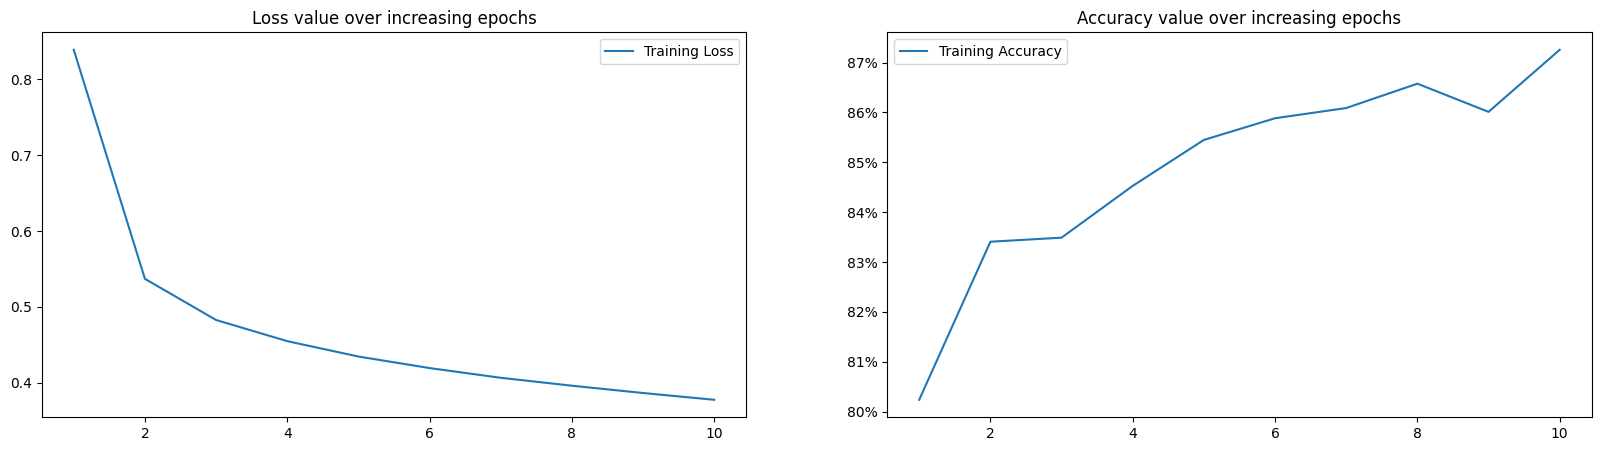

In [259]:
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl

trn_dl = get_data()
model, loss_fn, optimizer = get_model()

losses, accuracies = [], []
for epoch in range(10):
    print(epoch)
    epoch_losses, epoch_accuracies = [], []
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        epoch_losses.append(batch_loss)
    epoch_loss = np.array(epoch_losses).mean()
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        epoch_accuracies.extend(is_correct)
    epoch_accuracy = np.mean(epoch_accuracies)
    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)

epochs = np.arange(10)+1
import matplotlib.pyplot as plt
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.title('Loss value over increasing epochs')
plt.plot(epochs, losses, label='Training Loss')
plt.legend()
plt.subplot(122)
plt.title('Accuracy value over increasing epochs')
plt.plot(epochs, accuracies, label='Training Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
plt.show()

如上图所示，训练损失不断减少，训练准确率不断提高，可以将准确率提高到约 87%。

接下来，我们将了解缩放数据集能使神经网络性能更好的原因。假设输入数据未缩放，以计算 sigmoid 值为例：  
| 输入 | 权重 | 偏置 | sigmoid 值 |
| :---: | :---: | :---: | :---: |
| 255  | 0.01 | 0    | 0.93       |
| 255  | 0.1  | 0    | 1.00       |
| 255  | 0.2  | 0    | 1.00       |
| 255  | 0.4  | 0    | 1.00       |
| 255  | 0.8  | 0    | 1.00       |
| 255  | 1.6  | 0    | 1.00       |
| 255  | 3.2  | 0    | 1.00       |
| 255  | 6.4  | 0    | 1.00       |

在上表中，即使权重值在 0.01 到 6.4 之间变化，在经过函数 Sigmoid 后输出变化也不大。Sigmoid 函数的计算公式如下：  
$$
output = \frac{1}{1 + e^{-(w*x + b)}}
$$  
其中 w 是权重， x 是输入，b 是偏置值。Sigmoid 输出不变的原因是由于 w*x 的乘积很大(因为 x 较大)，导致 Sigmoid 值始终落在 Sigmoid 曲线的饱和部分中( Sigmoid 曲线的右上角或左下角的值称为饱和部分)。  

如果我们将不同的权重值乘以一个较小的输入数字，如下所示：  
| 输入 | 权重 | 偏置 | sigmoid 值 |
| :---: | :---: | :---: | :---: |
| 1 | 0.01 | 0 | 0.50 |
| 1 | 0.1  | 0 | 0.52 |
| 1 | 0.2  | 0 | 0.55 |
| 1 | 0.4  | 0 | 0.60 |
| 1 | 0.8  | 0 | 0.69 |
| 1 | 1.6  | 0 | 0.83 |
| 1 | 3.2  | 0 | 0.96 |
| 1 | 6.4  | 0 | 1.00 |  

由于输入值较小，因此上表中的 Sigmoid 输出的变化幅度较大。通过此示例，我们了解了缩放输入对数据集的影响，当权重(假设权重不具有较大范围)乘以输入值时，产生的值范围空间并不会突变，从而使输入数据能够对输出产生足够重要的影响。  

当权重值也很大时，输入值对输出的影响也将变得不太重要。因此，我们一般将权重值初始化为更接近零的较小数值。同时，为了获得最佳的权重值，通常设置初始权重的范围变化不大，比如权重初始化为介于 -1 和 +1 之间的随机值。  

## 4. 修改优化器  
不同优化器同样可能会影响模型学习拟合输入和输出的速度，在本节中，将了解修改优化器对模型准确性的影响。为了便于比较随机梯度下降( Stochastic Gradient Descent, SGD )和 Adam 在更多 epoch 上的性能，将 epoch 修改为 20。  

1. 修改优化器，在 get_model() 函数中使用 SGD 优化器，同时确保其他设定保持不变：

In [260]:
from torch.optim import SGD, Adam
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer


2. 增加训练模型的 epoch 数：

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


C:\Users\Admin\AppData\Local\Temp\ipykernel_26548\2822831218.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


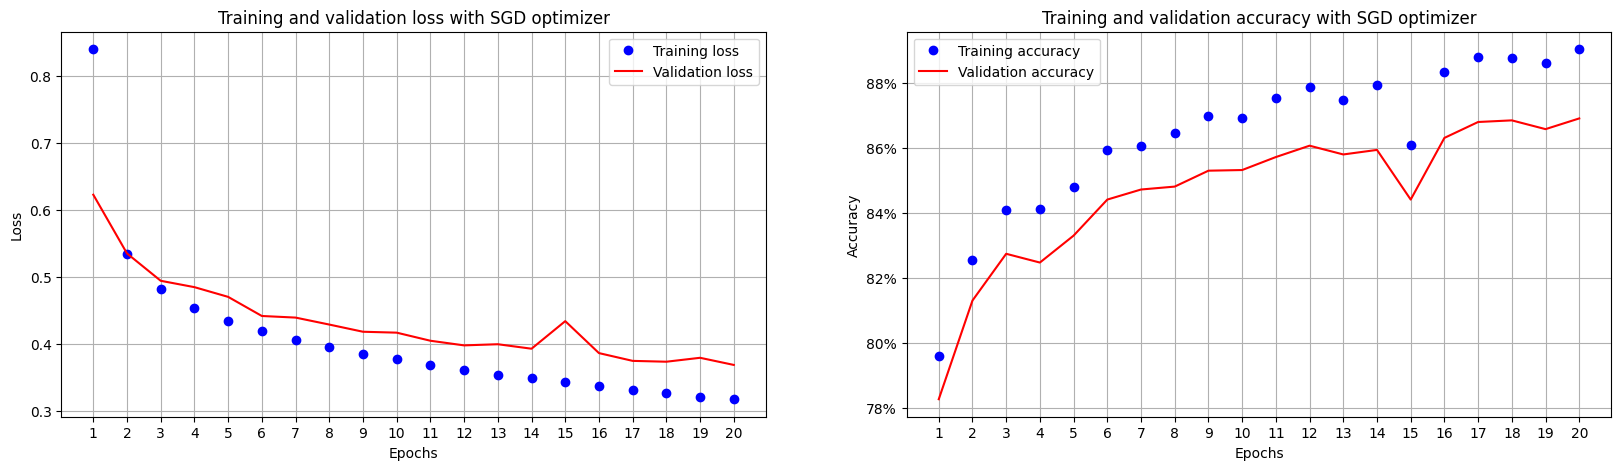

In [262]:
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=32, shuffle=False)
    return trn_dl, val_dl

trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(20):
    print(epoch)
    train_epoch_losses, train_epoch_accuracies = [], []
    val_epoch_losses, val_epoch_accuracies = [], []
    
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()
    
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)
    
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model, loss_fn)
        val_epoch_losses.append(validation_loss)
        val_epoch_accuracies.extend(val_is_correct)
    val_epoch_accuracy = np.mean(val_epoch_accuracies)
    val_accuracies.append(val_epoch_accuracy)
    val_epoch_loss = np.array(val_epoch_losses).mean()
    val_losses.append(val_epoch_loss)

epochs = np.arange(20)+1
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.figure(figsize=(20,5))
plt.subplot(121)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with SGD optimizer')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid('off')

plt.subplot(122)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with SGD optimizer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid('off')
plt.show()

进行这些更改后，优化器为 SGD 时，训练和验证数据集上的准确率和损失的变化  
- 将优化器修改为Adam：

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


C:\Users\Admin\AppData\Local\Temp\ipykernel_26548\786034706.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


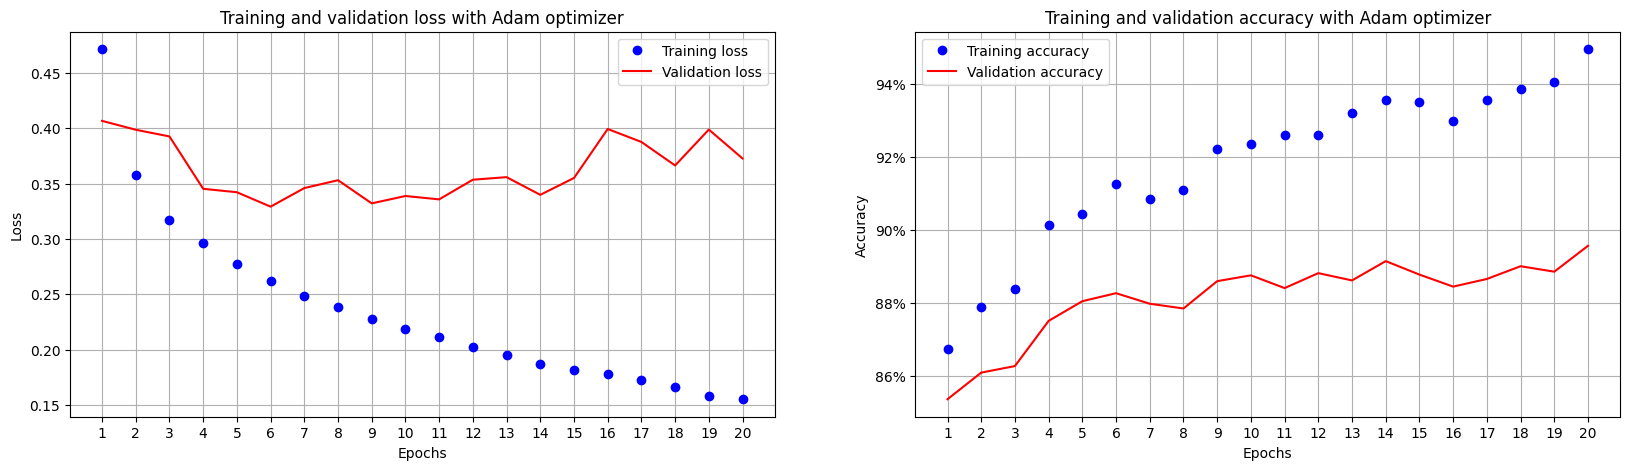

In [263]:
from torch.optim import SGD, Adam
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3)
    return model, loss_fn, optimizer
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=32, shuffle=False)
    return trn_dl, val_dl

trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(20):
    print(epoch)
    train_epoch_losses, train_epoch_accuracies = [], []
    val_epoch_losses, val_epoch_accuracies = [], []
    
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()
    
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)
    
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model, loss_fn)
        val_epoch_losses.append(validation_loss)
        val_epoch_accuracies.extend(val_is_correct)
    val_epoch_accuracy = np.mean(val_epoch_accuracies)
    val_accuracies.append(val_epoch_accuracy)
    val_epoch_loss = np.array(val_epoch_losses).mean()
    val_losses.append(val_epoch_loss)

epochs = np.arange(20)+1
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.figure(figsize=(20,5))
plt.subplot(121)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with Adam optimizer')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid('off')

plt.subplot(122)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with Adam optimizer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid('off')
plt.show()

在优化器为 Adam 时，训练和验证数据集上的准确率和损失值的变化如上  

与其他优化器相比，Adam 通常优化器可以更快地实现最佳准确率，其他一些可用的优化器包括 Adagrad、Adadelta、AdamW、LBFGS 和 RMSprop。

## 5. 构建深层神经网络  
到目前为止，我们构建的神经网络架构只有一个隐藏层。在本节中，我们将对比具有两个隐藏层和没有隐藏层的神经网络模型的性能。

1. 构建包含两层隐藏层的神经网络模型：

In [264]:
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 512),
        nn.ReLU(),
        nn.Linear(512, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3)
    return model, loss_fn, optimizer

2. 类似地，修改 get_model() 函数构建不含隐藏层的神经网络，将输入直接连接到输出层：

In [265]:
from torch.optim import SGD, Adam
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3)
    return model, loss_fn, optimizer

训练和验证数据集的准确率和损失变化如下所示：

![image](../Images/6.1.png)  

从以上结果可以看出：
- 当没有隐藏层时，模型无法学习数据集中的复杂模式
- 与一个隐藏层相比，当有两个隐藏层时，模型的过拟合会更严重 
   
深度神经网络意味着在输入层和输出层间存在多个隐藏层。多个隐藏层确保神经网络可以学习输入和输出之间的复杂非线性关系，而简单的神经网络则无法完成这样的需求(由于隐藏层数量有限)。  

## 小结  
神经网络性能优化技术是指通过改进神经网络的结构、参数初始化、正则化和训练过程等方面来提高其性能和泛化能力的方法。本节首先训练了一个简单的全连接网络，然后在此基础上介绍了简单有效的神经网络性能提升技巧，在之后的学习中，还将进一步介绍包括批归一化、动态学习率等常见技术。